In [2]:
# Scanpy (단일세포 분석 메인 툴), Leidenalg (클러스터링), GSEApy (패스웨이 분석) 설치
!pip install -q scanpy leidenalg gseapy xgboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 634.7/634.7 kB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.0/176.0 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 76.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 68.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the sou

In [3]:
# 2. 라이브러리 로드 및 기본 설정
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 머신러닝 라이브러리
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb

# 생물학적 패스웨이 해석 라이브러리
import gseapy as gp

# Scanpy 시각화 및 출력 설정
sc.settings.verbosity = 3
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

/tmp/ipykernel_1886/1994897473.py:20: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=80, facecolor='white')


In [4]:
# 3. 데이터 로드 (Data Loading)

"""
앞서 Cellxgene 등에서 다운로드한 .h5ad 파일을 불러옵니다.
(여기서는 코드가 바로 돌아가는지 테스트해 보실 수 있도록
Scanpy에서 제공하는 3천 개의 혈액세포 샘플 데이터를 기본으로 불러오겠습니다.
실전에서는 주석 처리된 줄을 사용하세요.)
"""
# 실전용 코드: 다운로드한 암 데이터 파일 경로를 입력하세요.
# adata = sc.read_h5ad('my_cancer_data.h5ad')

# 테스트용 코드: Scanpy 내장 PBMC(말초혈액단핵구) 데이터 로드
adata = sc.datasets.pbmc3k()

# 데이터 구조 확인 (세포 수 x 유전자 수)
print(adata)

try downloading from url
https://exampledata.scverse.org/scanpy/pbmc3k_raw.h5ad
... this may take a while but only happens once


  0%|          | 0.00/5.58M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'


In [5]:
# 4. 품질 관리 (QC - Quality Control)
"""
죽어가는 세포(미토콘드리아 유전자 발현 비율이 비정상적으로 높은 세포)나 빈 방울(Empty droplet)을 걸러냅니다.
"""

# 미토콘드리아 유전자(MT-) 비율 계산 (죽은 세포 필터링 목적)
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

# 1. 200개 이하의 유전자가 발현된 세포 제거 (빈 방울)
sc.pp.filter_cells(adata, min_genes=200)
# 2. 3개 이하의 세포에서 발현된 유전자 제거 (노이즈)
sc.pp.filter_genes(adata, min_cells=3)
# 3. 미토콘드리아 발현 비율이 5% 이상인 세포 제거 (죽어가는 세포)
adata = adata[adata.obs.pct_counts_mt < 5, :]

print(f"QC 후 남은 데이터: {adata.n_obs} 세포, {adata.n_vars} 유전자")

filtered out 19024 genes that are detected in less than 3 cells
QC 후 남은 데이터: 2643 세포, 13714 유전자


normalizing counts per cell


/tmp/ipykernel_1886/1980904000.py:9: UserWarning: Received a view of an AnnData. Making a copy.
  sc.pp.normalize_total(adata, target_sum=1e4)


    finished (0:00:05)
extracting highly variable genes
    finished (0:00:03)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


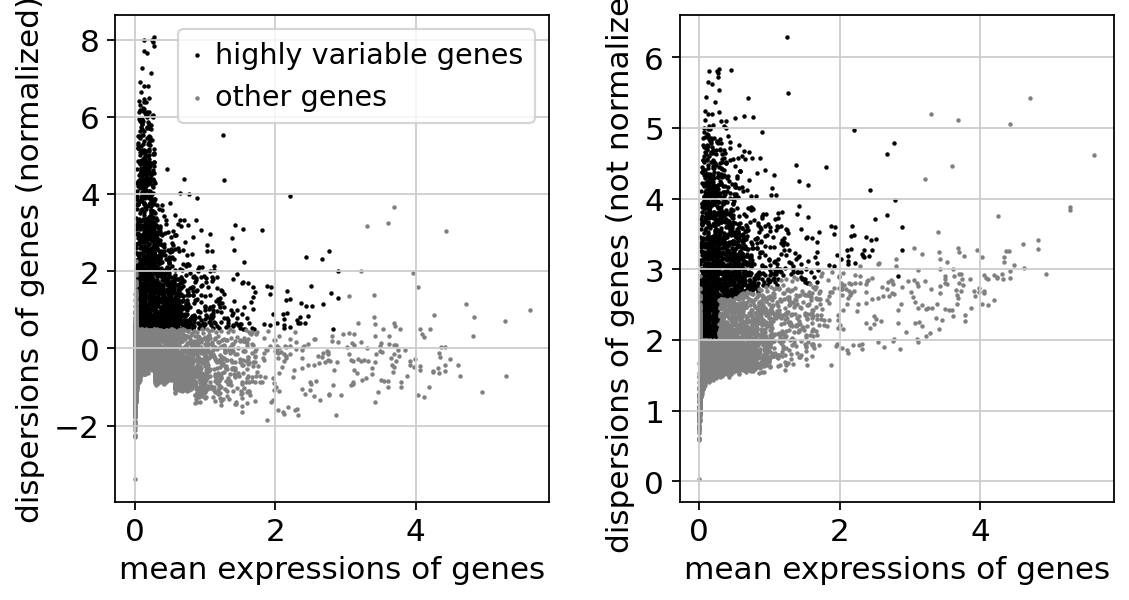

/usr/lib/python3.12/functools.py:912: UserWarning: Received a view of an AnnData. Making a copy.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [6]:
# 5. 정규화 및 고변동 유전자(HVG) 추출

"""
모든 세포의 시퀀싱 깊이가 다르므로
이를 맞춰주고(정규화), 세포 간의 차이를 가장 잘 보여주는 핵심 유전자들만 추려냅니다.
"""

# 총 발현량을 10,000으로 맞추고 로그 변환 (Log Normalize)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# 고변동 유전자(Highly Variable Genes) 추출
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

# 시각화
sc.pl.highly_variable_genes(adata)

# 분석의 효율성을 위해 고변동 유전자만 남김
adata = adata[:, adata.var.highly_variable]

# 데이터 스케일링 (Z-score 표준화)
sc.pp.scale(adata, max_value=10)

computing PCA
    with n_comps=50
    finished (0:00:02)
computing neighbors
    using 'X_pca' with n_pcs = 40
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:40)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:05)
running Leiden clustering


/tmp/ipykernel_1886/2968078840.py:15: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=0.5)


    finished: found 7 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


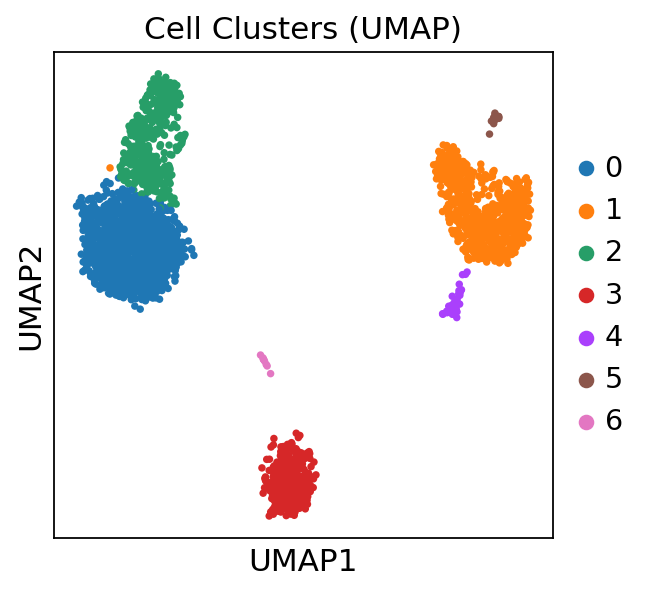

In [7]:
# 6. 차원 축소 및 클러스터링 (UMAP & Leiden)

"""
수천 개의 유전자 차원을 2차원으로 압축하여 지도를 그리고, 비슷한 세포끼리 군집화합니다.
"""

# PCA (주성분 분석)
sc.tl.pca(adata, svd_solver='arpack')

# 이웃 그래프 생성 및 UMAP 차원 축소
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)

# Leiden 알고리즘으로 세포 클러스터링 (유사한 세포끼리 묶기)
sc.tl.leiden(adata, resolution=0.5)

# UMAP 시각화
sc.pl.umap(adata, color=['leiden'], title='Cell Clusters (UMAP)')

In [8]:
# 7. 머신러닝을 이용한 세포 타입/암세포 분류기 (AI Modeling)

"""
여기서는 전통적인 통계 기반의 차별발현유전자(DEG) 분석을 넘어,
Random Forest 인공지능 모델을 사용하여
특정 클러스터(예: 암세포 군집)를 예측하고 중요한 유전자 피처(Biomarker)를 뽑아냅니다.
"""

# X 데이터 (유전자 발현량 매트릭스)
X = adata.X
# Y 데이터 (예측하고자 하는 타겟: 여기서는 Leiden 클러스터 라벨)
# 실전에서는 adata.obs['cell_type'] 이나 'cancer_status' 등을 사용합니다.
y = adata.obs['leiden'].astype(str)

# 학습 데이터와 테스트 데이터 분리 (8:2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest 분류기 모델 학습
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 예측 및 성능 평가
y_pred = rf_model.predict(X_test)
print("=== 분류기 성능 평가 ===")
print(classification_report(y_test, y_pred))

=== 분류기 성능 평가 ===
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       249
           1       0.96      1.00      0.98       117
           2       0.97      0.97      0.97        88
           3       0.95      0.98      0.97        63
           4       1.00      0.44      0.62         9
           5       0.00      0.00      0.00         1
           6       0.00      0.00      0.00         2

    accuracy                           0.97       529
   macro avg       0.69      0.62      0.64       529
weighted avg       0.96      0.97      0.96       529



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


=== AI 모델이 선정한 핵심 바이오마커 Top 20 ===
          Gene  Importance
1593      CST7    0.032015
1592      CST3    0.027252
599   HLA-DRB1    0.024658
1803    LGALS1    0.023625
145     FCER1G    0.020778
606   HLA-DPA1    0.020539
120     S100A6    0.020509
607   HLA-DPB1    0.020157
1426      CYBA    0.019797
897       FCN1    0.019180
591       AIF1    0.018479
1013     MS4A1    0.017967
110       CTSS    0.017732
504       GZMA    0.017643
1529     CD79B    0.017576
940       PRF1    0.017286
1481      CCL5    0.017041
1354      IL32    0.016977
600   HLA-DQA1    0.016898
601   HLA-DQB1    0.016512


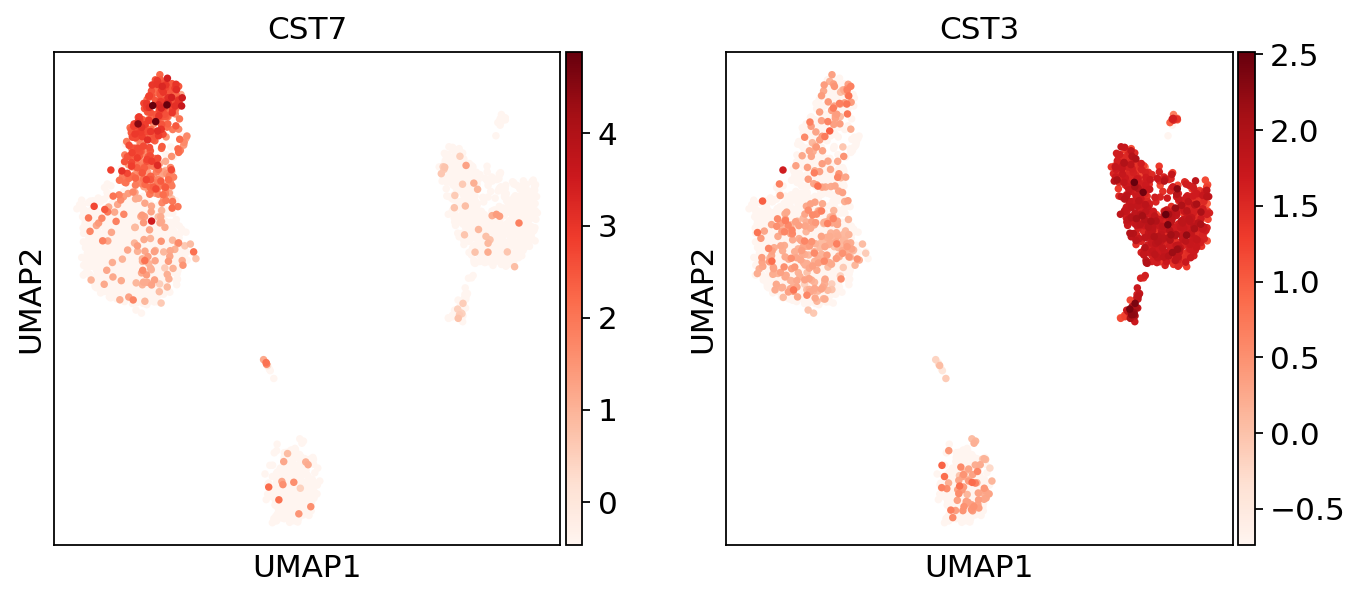

In [9]:
# 8. AI가 선택한 핵심 바이오마커(유전자) 추출

"""
머신러닝 모델이 암세포를 구별할 때 가장 중요하게 생각한 유전자(Feature Importance) 순위를 매깁니다.
"""

# 중요도 순으로 유전자 정렬
feature_importances = pd.DataFrame({
    'Gene': adata.var_names,
    'Importance': rf_model.feature_importances_
})
top_biomarkers = feature_importances.sort_values(by='Importance', ascending=False).head(20)

print("=== AI 모델이 선정한 핵심 바이오마커 Top 20 ===")
print(top_biomarkers)

# 주요 유전자 발현량을 UMAP 위에 색상으로 시각화 (첫 2개 유전자만 확인)
top_genes_list = top_biomarkers['Gene'].tolist()[:2]
sc.pl.umap(adata, color=top_genes_list, cmap='Reds')

=== 핵심 바이오마커 관련 생물학적 기작 (KEGG Pathways) ===


,Term,Overlap,P-value,Adjusted P-value
0,Allograft rejection,8/38,3.913327e-14,2.835712e-12
1,Graft-versus-host disease,8/42,9.374779e-14,2.835712e-12
2,Type I diabetes mellitus,8/43,1.149613e-13,2.835712e-12
3,Autoimmune thyroid disease,8/53,6.896787e-13,1.275906e-11
4,Asthma,7/31,9.891545e-13,1.463949e-11
5,Rheumatoid arthritis,8/93,7.353828e-11,9.069721e-10
6,Hematopoietic cell lineage,8/99,1.222419e-10,1.272490e-09
7,Viral myocarditis,7/60,1.375665e-10,1.272490e-09
8,Tuberculosis,9/180,5.780667e-10,4.752993e-09
9,Leishmaniasis,7/77,8.296026e-10,6.119660e-09


<Axes: title={'center': 'Pathway Analysis of AI Biomarkers'}, xlabel='$- \\log_{10}$ (Adjusted P-value)'>

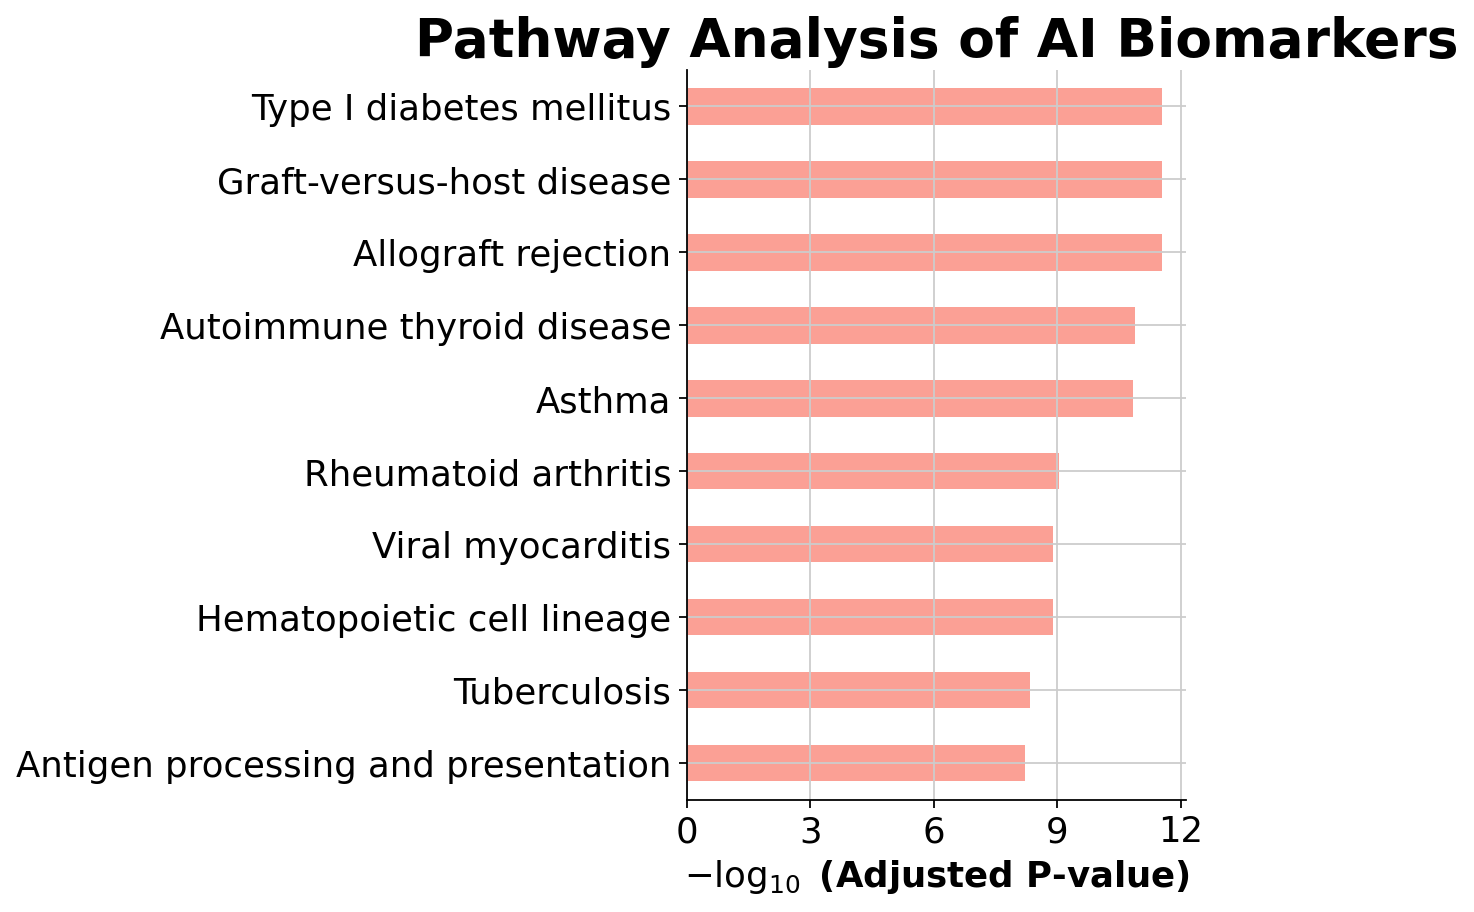

In [10]:
# 9. 생물학적 해석 (Pathway / GO 분석)

"""
AI가 찾은 바이오마커가 그저 숫자 노름이 아님을 증명하는 가장 중요한 단계.
이 유전자들이 세포 내에서 어떤 신호전달 경로(예: Apoptosis, MAPK, GPCR)에 관여하는지 밝혀.
"""

# AI가 찾은 Top 50 바이오마커 리스트 추출
gene_list = feature_importances.sort_values(by='Importance', ascending=False).head(50)['Gene'].tolist()

# Enrichr를 이용한 GO(Gene Ontology) 분석
# 'KEGG_2021_Human' 또는 'GO_Biological_Process_2021' 데이터베이스 사용
enrichment_result = gp.enrichr(gene_list=gene_list,
                               gene_sets='KEGG_2021_Human',
                               organism='human',
                               outdir=None)

# 유의미한 패스웨이 결과 출력 (P-value 기준 정렬)
significant_pathways = enrichment_result.res2d.sort_values(by='P-value').head(10)
print("=== 핵심 바이오마커 관련 생물학적 기작 (KEGG Pathways) ===")
display(significant_pathways[['Term', 'Overlap', 'P-value', 'Adjusted P-value']])

# 시각화 (Bar plot)
gp.barplot(enrichment_result.res2d, title="Pathway Analysis of AI Biomarkers")